<a href="https://colab.research.google.com/github/NupoorRaut/Deep-Learning/blob/main/04_DNN_vs_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cipher 10, 100
tensorflow dataset

4a: DNN
input layer ()
flatten layer()

4b: CNN


##DNN V/S CNN
~Dataset CIFAR 10, 100
LR- 0.001 , 0.01
Optimiser- ADAM , SGD
ACtivation - RELU , tanh

CIFAR-10

60,000 images (32×32 RGB)

10 classes (airplane, car, bird, etc.)

6,000 images per class



CIFAR-100

Same size images

100 classes → harder problem

Only 600 images per class

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


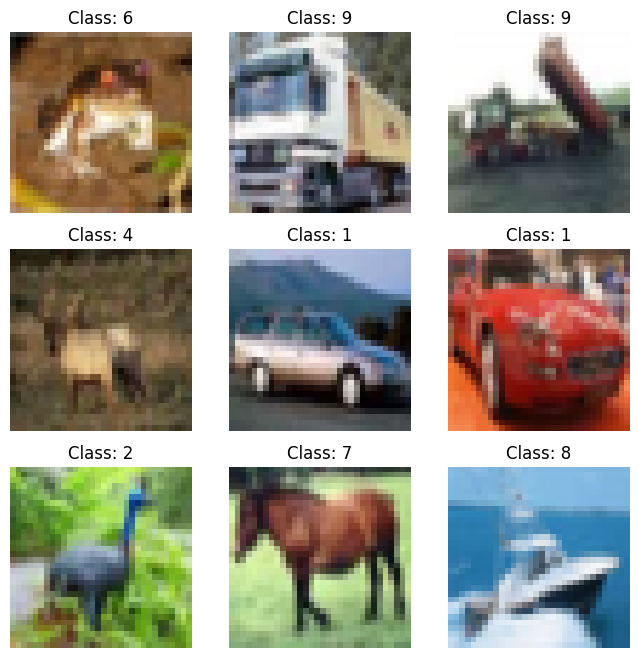

In [ ]:
# Sample images
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(f"Class: {y_train[i][0]}")
    plt.axis('off')
plt.show()

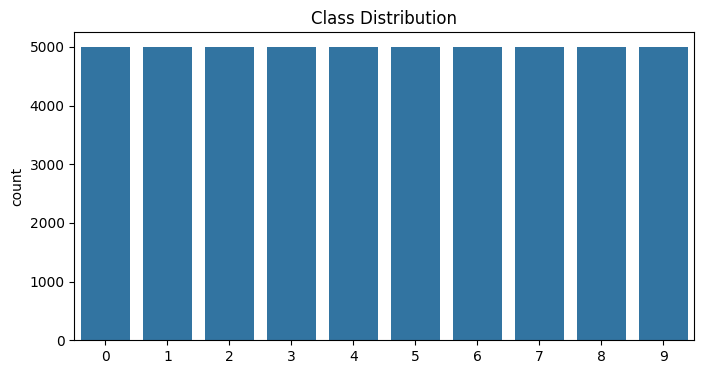

In [ ]:
# Class distribution
plt.figure(figsize=(8,4))
sns.countplot(x=y_train.flatten())
plt.title("Class Distribution")
plt.show()

Preprocessing


In [ ]:
# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0


In [ ]:
# Flatten images
x_train = x_train.reshape(len(x_train), -1)
x_test = x_test.reshape(len(x_test), -1)

In [ ]:
# Train-validation split
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)


In [ ]:
print("Train:", x_train.shape)
print("Validation:", x_val.shape)

Train: (40000, 3072)
Validation: (10000, 3072)


In [ ]:
def build_model(activation, optimizer):
    model1 = Sequential([
        Dense(512, activation=activation, input_shape=(3072,)),
        Dense(256, activation=activation),
        Dense(10, activation='softmax')
    ])

    model1.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model1

In [ ]:
configs = [
    ("relu", Adam(learning_rate=0.001)),
    ("relu", Adam(learning_rate=0.01)),
    ("tanh", Adam(learning_rate=0.001)),
    ("tanh", Adam(learning_rate=0.01)),
    ("relu", SGD(learning_rate=0.001)),
    ("relu", SGD(learning_rate=0.01)),
    ("tanh", SGD(learning_rate=0.001)),
    ("tanh", SGD(learning_rate=0.01)),
]

history_dict = {}
results = []

In [ ]:
for act, opt in configs:
    name = f"{act}_{type(opt).__name__}_{opt.learning_rate.numpy()}"
    print(f"\nTraining: {name}")

    model = build_model(act, opt)

    history = model.fit(
        x_train, y_train,
        epochs=10,
        validation_data=(x_val, y_val),
        verbose=1
    )

    val_acc = history.history['val_accuracy'][-1]

    history_dict[name] = history
    results.append((name, val_acc))



Training: relu_Adam_0.0010000000474974513


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2840 - loss: 1.9503 - val_accuracy: 0.3441 - val_loss: 1.8176
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3627 - loss: 1.7566 - val_accuracy: 0.3833 - val_loss: 1.6952
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3939 - loss: 1.6741 - val_accuracy: 0.3961 - val_loss: 1.6593
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4177 - loss: 1.6160 - val_accuracy: 0.4100 - val_loss: 1.6270
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4388 - loss: 1.5674 - val_accuracy: 0.4297 - val_loss: 1.5831
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4523 - loss: 1.5283 - val_accuracy: 0.4516 - val_loss: 1.5275
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.4665 - loss: 1.4920 - val_accuracy: 0.4511 - val_loss: 1.5253
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4798 - loss: 1.4623 - 

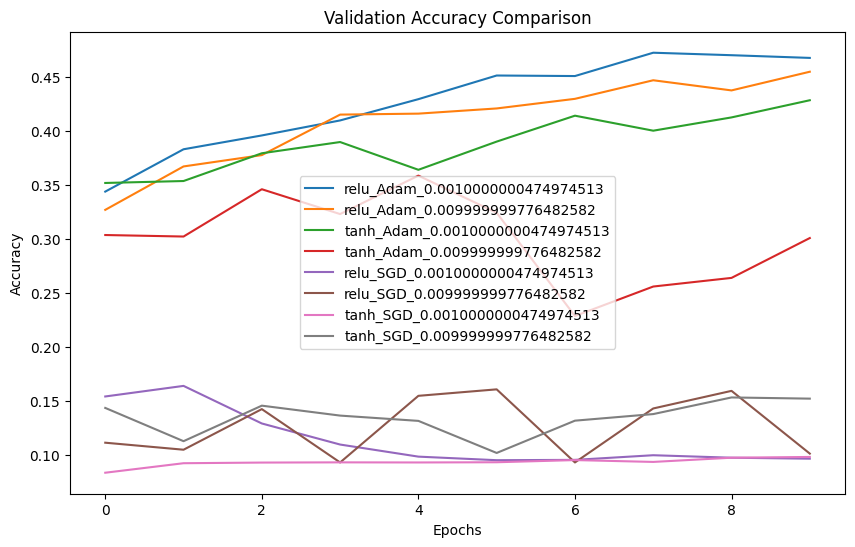

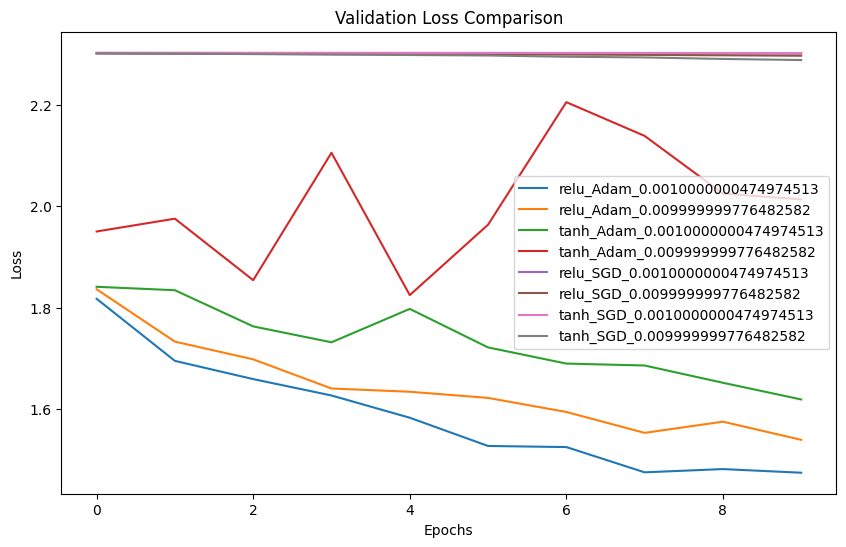

In [ ]:
# Accuracy plot
plt.figure(figsize=(10,6))
for key in history_dict:
    plt.plot(history_dict[key].history['val_accuracy'], label=key)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(10,6))
for key in history_dict:
    plt.plot(history_dict[key].history['val_loss'], label=key)

plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [ ]:
# ==============================
# 9. BEST MODEL SELECTION
# ==============================
best_config = max(results, key=lambda x: x[1])
print("\nBest Model:", best_config)

best_name = best_config[0]

# Extract parameters
if "relu" in best_name:
    activation = "relu"
else:
    activation = "tanh"

if "Adam" in best_name:
    if "0.001" in best_name:
        optimizer = Adam(0.001)
    else:
        optimizer = Adam(0.01)
else:
    if "0.001" in best_name:
        optimizer = SGD(0.001)
    else:
        optimizer = SGD(0.01)


Best Model: ('relu_Adam_0.0010000000474974513', 0.46790000796318054)


In [ ]:
history_dnn = final_model1.fit(
    x_train, y_train,
    epochs=15,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5192 - loss: 1.3426 - val_accuracy: 0.4830 - val_loss: 1.4618
Epoch 2/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5257 - loss: 1.3246 - val_accuracy: 0.4929 - val_loss: 1.4541
Epoch 3/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5330 - loss: 1.3069 - val_accuracy: 0.4940 - val_loss: 1.4316
Epoch 4/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5368 - loss: 1.2897 - val_accuracy: 0.4849 - val_loss: 1.4561
Epoch 5/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5428 - loss: 1.2767 - val_accuracy: 0.5004 - val_loss: 1.4178
Epoch 6/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5487 - loss: 1.2563 - val_accuracy: 0.5021 - val_loss: 1.4209
Epoch 7/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5566 - loss: 1.2453 - val_accuracy: 0.5030 - val_loss: 1.4110
Epoch 8/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5632 - loss: 1.2248 - 

In [ ]:
# ==============================
# 11. TEST EVALUATION
# ==============================
test_loss, test_acc = final_model.evaluate(x_test, y_test)

print("\nTest Accuracy:", test_acc)

# ==============================
# 12. PREDICTIONS
# ==============================
y_pred = final_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4844 - loss: 1.4626

Test Accuracy: 0.4844000041484833
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


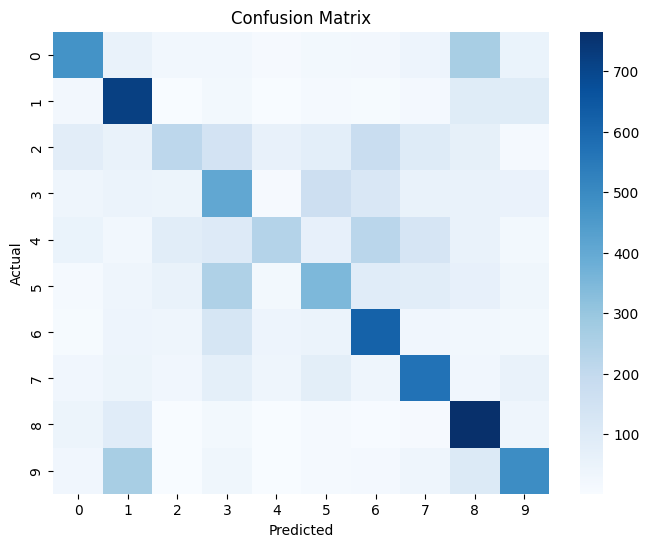


Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.47      0.53      1000
           1       0.52      0.72      0.60      1000
           2       0.43      0.21      0.29      1000
           3       0.34      0.41      0.37      1000
           4       0.55      0.23      0.33      1000
           5       0.41      0.35      0.38      1000
           6       0.47      0.62      0.53      1000
           7       0.53      0.57      0.55      1000
           8       0.50      0.77      0.60      1000
           9       0.56      0.49      0.53      1000

    accuracy                           0.48     10000
   macro avg       0.49      0.48      0.47     10000
weighted avg       0.49      0.48      0.47     10000



In [ ]:
# ==============================
# 13. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==============================
# 14. CLASSIFICATION REPORT
# ==============================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))

##CIFAR 100

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


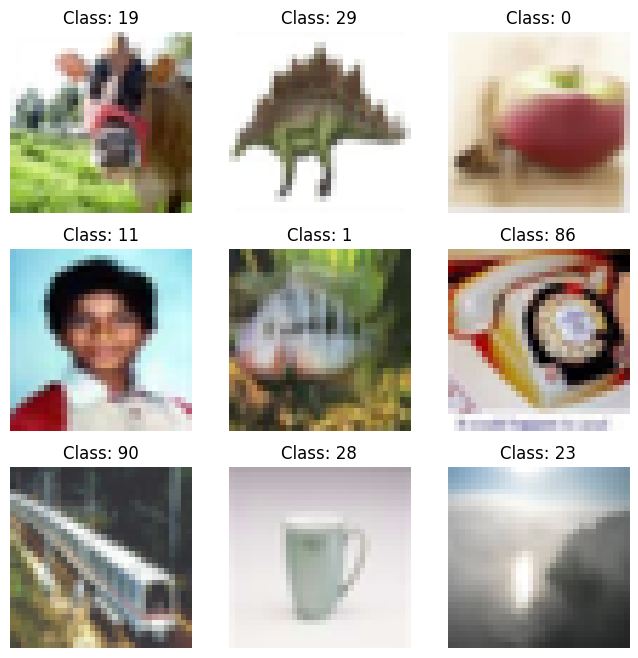


Training: relu_Adam_0.0010000000474974513


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.0758 - loss: 4.0913 - val_accuracy: 0.1170 - val_loss: 3.7897
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1317 - loss: 3.6964 - val_accuracy: 0.1460 - val_loss: 3.6217
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1617 - loss: 3.5376 - val_accuracy: 0.1700 - val_loss: 3.5317
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1822 - loss: 3.4349 - val_accuracy: 0.1760 - val_loss: 3.4726
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1949 - loss: 3.3527 - val_accuracy: 0.1741 - val_loss: 3.4871
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2057 - loss: 3.2830 - val_accuracy: 0.1877 - val_loss: 3.4181
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2153 - loss: 3.2308 - val_accuracy: 0.1986 - val_loss: 3.3847
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2262 - loss: 3.1823 - 

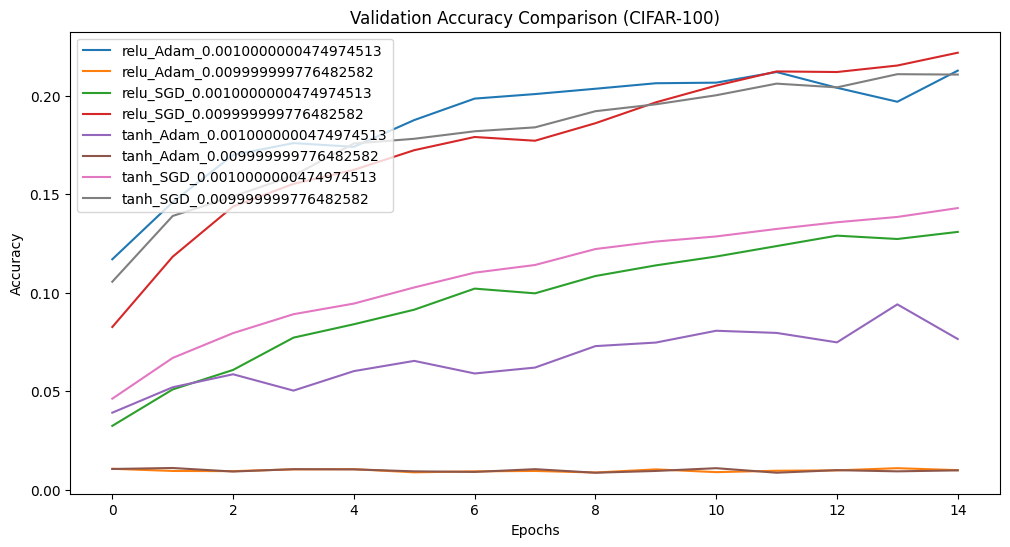

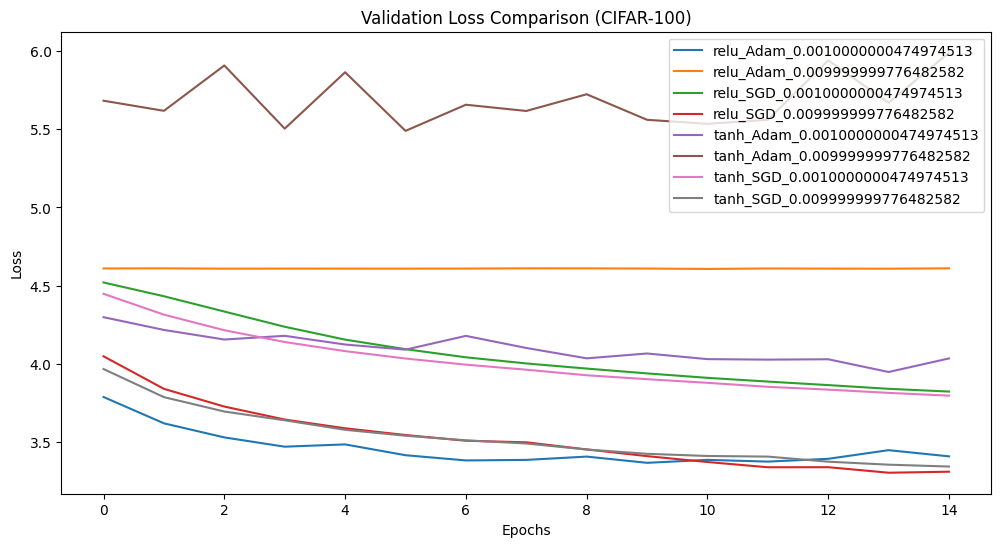


Best Configuration:
 Activation                relu
Optimizer                  SGD
Learning Rate             0.01
Train Accuracy            0.26
Validation Accuracy     0.2219
Validation Loss        3.31274
Name: 3, dtype: object


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.0589 - loss: 4.2870
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1076 - loss: 3.9227
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.1358 - loss: 3.7506
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1550 - loss: 3.6423
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1727 - loss: 3.5606
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.1843 - loss: 3.4905
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.1958 - loss: 3.4318
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2034 - loss: 3.3791
Epoch 9/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2125 - loss: 3.3284
Epoch 10/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2206 - loss: 3.2820
Epoch 11/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2290 - loss: 3.2355
Epoch 12/15
1250/1250 ━━━━━━━━

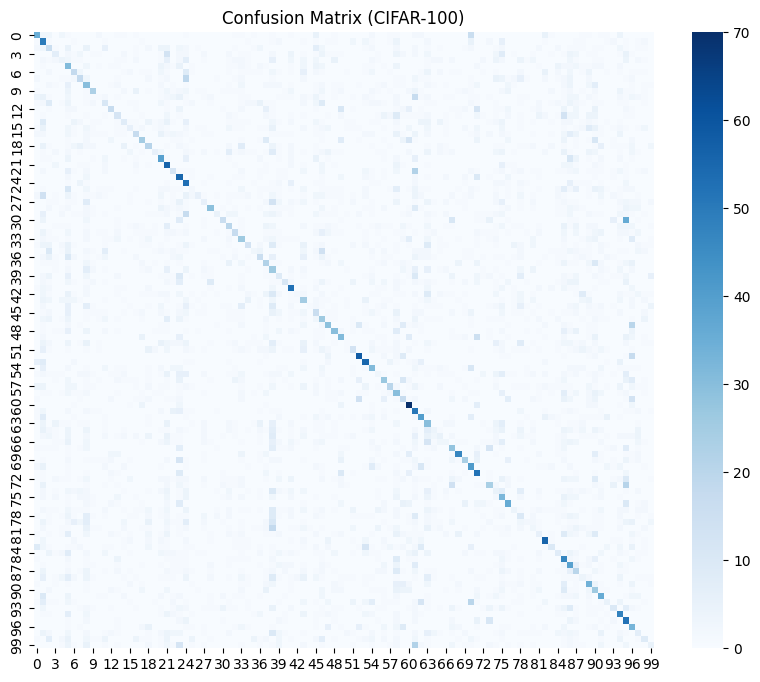


Classification Report:

              precision    recall  f1-score   support

           0       0.41      0.35      0.38       100
           1       0.18      0.50      0.27       100
           2       0.14      0.16      0.15       100
           3       0.16      0.07      0.10       100
           4       0.11      0.04      0.06       100
           5       0.11      0.31      0.16       100
           6       0.25      0.18      0.21       100
           7       0.29      0.18      0.22       100
           8       0.14      0.30      0.19       100
           9       0.41      0.23      0.29       100
          10       0.05      0.01      0.02       100
          11       0.14      0.11      0.12       100
          12       0.38      0.17      0.23       100
          13       0.19      0.12      0.15       100
          14       0.17      0.08      0.11       100
          15       0.18      0.06      0.09       100
          16       0.30      0.17      0.22       100
  

In [ ]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD

# ==============================
# 2. LOAD CIFAR-100 DATA
# ==============================
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

# ==============================
# 3. EDA
# ==============================

# Show sample images
plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(f"Class: {y_train[i][0]}")
    plt.axis('off')
plt.show()

# ==============================
# 4. PREPROCESSING
# ==============================

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten
x_train = x_train.reshape(len(x_train), -1)
x_test = x_test.reshape(len(x_test), -1)

# Train-validation split
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

# ==============================
# 5. MODEL BUILDER
# ==============================
def build_model(activation, optimizer):
    model = Sequential([
        Dense(512, activation=activation, input_shape=(3072,)),
        Dense(256, activation=activation),
        Dense(100, activation='softmax')  # CIFAR-100 → 100 classes
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# ==============================
# 6. CONFIGURATIONS (ALL COMBINATIONS)
# ==============================
configs = [
    ("relu", Adam(0.001)),
    ("relu", Adam(0.01)),
    ("relu", SGD(0.001)),
    ("relu", SGD(0.01)),
    ("tanh", Adam(0.001)),
    ("tanh", Adam(0.01)),
    ("tanh", SGD(0.001)),
    ("tanh", SGD(0.01)),
]

history_dict = {}
results = []

# ==============================
# 7. TRAIN MODELS (EPOCHS = 15)
# ==============================
for act, opt in configs:
    name = f"{act}_{type(opt).__name__}_{opt.learning_rate.numpy()}"
    print(f"\nTraining: {name}")

    model = build_model(act, opt)

    history = model.fit(
        x_train, y_train,
        epochs=15,
        validation_data=(x_val, y_val),
        verbose=1
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    val_loss = history.history['val_loss'][-1]

    history_dict[name] = history

    results.append({
        "Activation": act,
        "Optimizer": type(opt).__name__,
        "Learning Rate": float(opt.learning_rate.numpy()),
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Validation Loss": val_loss
    })

# ==============================
# 8. COMPARISON MATRIX
# ==============================
results_df = pd.DataFrame(results)

print("\n===== COMPARISON MATRIX =====\n")
print(results_df.sort_values(by="Validation Accuracy", ascending=False))

# ==============================
# 9. VISUALIZATION
# ==============================

# Accuracy comparison
plt.figure(figsize=(12,6))
for key in history_dict:
    plt.plot(history_dict[key].history['val_accuracy'], label=key)

plt.title("Validation Accuracy Comparison (CIFAR-100)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss comparison
plt.figure(figsize=(12,6))
for key in history_dict:
    plt.plot(history_dict[key].history['val_loss'], label=key)

plt.title("Validation Loss Comparison (CIFAR-100)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ==============================
# 10. BEST MODEL SELECTION
# ==============================
best_row = results_df.loc[results_df["Validation Accuracy"].idxmax()]
print("\nBest Configuration:\n", best_row)

# ==============================
# 11. FINAL MODEL TRAINING
# ==============================
activation = best_row["Activation"]

if best_row["Optimizer"] == "Adam":
    optimizer = Adam(best_row["Learning Rate"])
else:
    optimizer = SGD(best_row["Learning Rate"])

final_model = build_model(activation, optimizer)

final_model.fit(x_train, y_train, epochs=15, verbose=1)

# ==============================
# 12. TEST EVALUATION
# ==============================
test_loss, test_acc = final_model.evaluate(x_test, y_test)

print("\nTest Accuracy:", test_acc)

# ==============================
# 13. PREDICTIONS
# ==============================
y_pred = final_model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# ==============================
# 14. CONFUSION MATRIX
# ==============================
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix (CIFAR-100)")
plt.show()

# ==============================
# 15. CLASSIFICATION REPORT
# ==============================
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))

##CNN

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD

In [ ]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Train-validation split
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

In [ ]:
def build_cnn(activation, optimizer):
    model = Sequential([

        Conv2D(32, (3,3), activation=activation, input_shape=(32,32,3)),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation=activation),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation=activation),

        Flatten(),

        Dense(128, activation=activation),
        Dropout(0.5),

        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
configs = [
    ("relu", Adam(0.001)),
    ("tanh", Adam(0.001)),
    ("relu", SGD(0.001)),

    ("tanh", SGD(0.001)),
   ]

In [ ]:
history_dict = {}
results = []

for act, opt in configs:
    name = f"{act}_{type(opt).__name__}_{opt.learning_rate.numpy()}"
    print(f"\nTraining: {name}")

    model = build_cnn(act, opt)

    history = model.fit(
        x_train, y_train,
        epochs=15,
        validation_data=(x_val, y_val),
        verbose=1
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    val_loss = history.history['val_loss'][-1]

    history_dict[name] = history

    results.append({
        "Activation": act,
        "Optimizer": type(opt).__name__,
        "Learning Rate": float(opt.learning_rate.numpy()),
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Validation Loss": val_loss
    })


Training: relu_Adam_0.0010000000474974513
Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.3939 - loss: 1.6535 - val_accuracy: 0.5225 - val_loss: 1.3201
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5329 - loss: 1.3167 - val_accuracy: 0.5910 - val_loss: 1.1559
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5944 - loss: 1.1536 - val_accuracy: 0.6380 - val_loss: 1.0186
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6372 - loss: 1.0360 - val_accuracy: 0.6651 - val_loss: 0.9454
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6681 - loss: 0.9499 - val_accuracy: 0.6788 - val_loss: 0.9201
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6932 - loss: 0.8810 - val_accuracy: 0.6845 - val_loss: 0.9003
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7138 - loss: 0.8229 - val_accuracy: 0.6780 - val_loss: 0.9357
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4

In [ ]:
results_df = pd.DataFrame(results)

print("\n===== CNN COMPARISON MATRIX =====\n")
print(results_df.sort_values(by="Validation Accuracy", ascending=False))


===== CNN COMPARISON MATRIX =====

  Activation Optimizer  Learning Rate  Train Accuracy  Validation Accuracy  \
0       relu      Adam          0.001        0.813550               0.7155   
1       tanh      Adam          0.001        0.698225               0.6549   
3       tanh       SGD          0.001        0.445125               0.4659   
2       relu       SGD          0.001        0.368525               0.4121   

   Validation Loss  
0         0.928349  
1         1.005964  
3         1.503640  
2         1.638417  


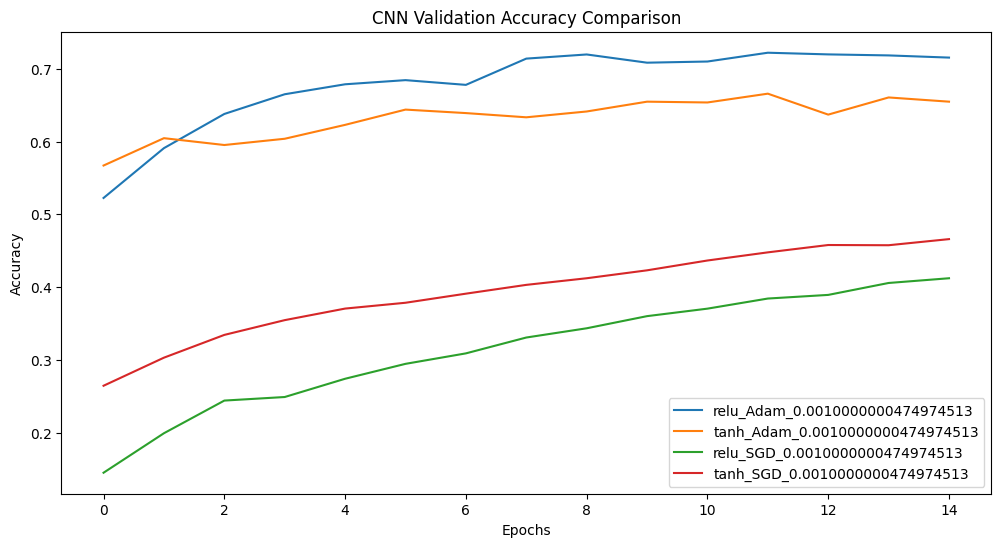

In [ ]:
plt.figure(figsize=(12,6))

for key in history_dict:
    plt.plot(history_dict[key].history['val_accuracy'], label=key)

plt.title("CNN Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

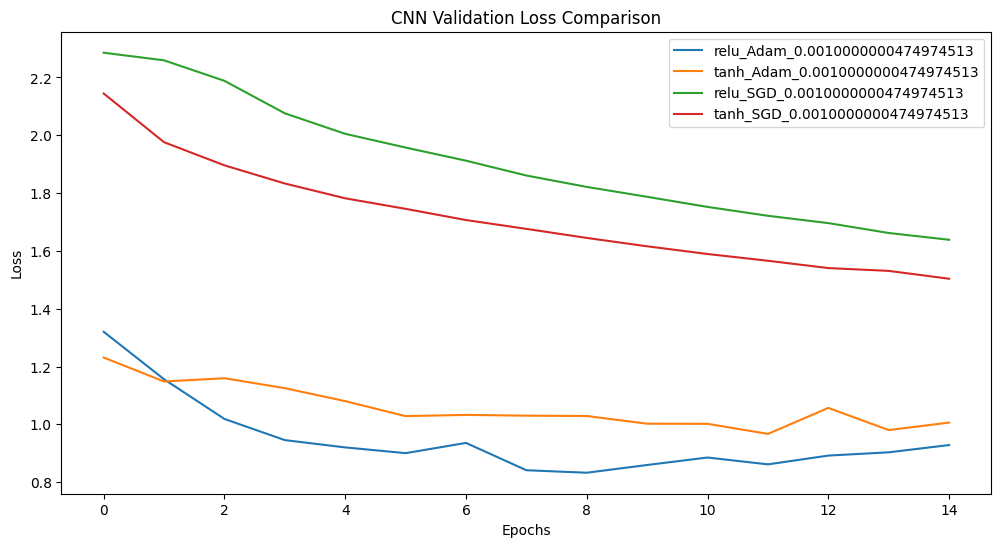

In [ ]:
plt.figure(figsize=(12,6))

for key in history_dict:
    plt.plot(history_dict[key].history['val_loss'], label=key)

plt.title("CNN Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
best_row = results_df.loc[results_df["Validation Accuracy"].idxmax()]
print("\nBest CNN Configuration:\n", best_row)


Best CNN Configuration:
 Activation                 relu
Optimizer                  Adam
Learning Rate             0.001
Train Accuracy          0.81355
Validation Accuracy      0.7155
Validation Loss        0.928349
Name: 0, dtype: object


In [ ]:
activation = best_row["Activation"]

if best_row["Optimizer"] == "Adam":
    optimizer = Adam(best_row["Learning Rate"])
else:
    optimizer = SGD(best_row["Learning Rate"])

final_cnn = build_cnn(activation, optimizer)

final_cnn.fit(x_train, y_train, epochs=15, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3848 - loss: 1.6734
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5340 - loss: 1.3114
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5917 - loss: 1.1581
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6345 - loss: 1.0499
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6633 - loss: 0.9712
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6847 - loss: 0.8985
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7063 - loss: 0.8423
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7218 - loss: 0.7933
Epoch 9/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7406 - loss: 0.7446
Epoch 10/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7502 - loss: 0.7092
Epoch 11/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7663 - loss: 0.6592
Epoch 12/15
1250/1250 ━━━━━━━━

In [ ]:
history_cnn = final_cnn.fit(
    x_train, y_train,
    epochs=15,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8132 - loss: 0.5101 - val_accuracy: 0.7098 - val_loss: 0.9745
Epoch 2/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8255 - loss: 0.4826 - val_accuracy: 0.7139 - val_loss: 0.9958
Epoch 3/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8299 - loss: 0.4661 - val_accuracy: 0.7181 - val_loss: 0.9951
Epoch 4/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8381 - loss: 0.4452 - val_accuracy: 0.7137 - val_loss: 1.0166
Epoch 5/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8465 - loss: 0.4260 - val_accuracy: 0.7156 - val_loss: 1.0778
Epoch 6/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8508 - loss: 0.4061 - val_accuracy: 0.7190 - val_loss: 1.0804
Epoch 7/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8553 - loss: 0.3967 - val_accuracy: 0.7117 - val_loss: 1.1235
Epoch 8/15
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8601 - loss: 0.3809 - 

In [ ]:
test_loss, test_acc = final_cnn.evaluate(x_test, y_test)
print("\nCNN Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6950 - loss: 1.0819

CNN Test Accuracy: 0.6949999928474426


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


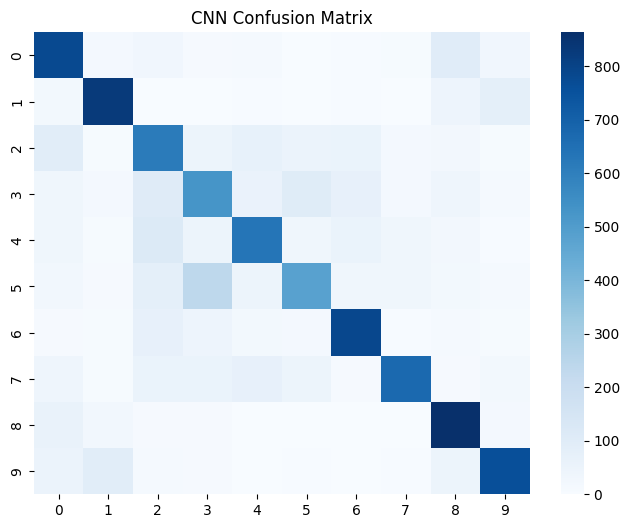

              precision    recall  f1-score   support

           0       0.67      0.78      0.72      1000
           1       0.80      0.83      0.81      1000
           2       0.56      0.62      0.58      1000
           3       0.52      0.53      0.53      1000
           4       0.68      0.63      0.66      1000
           5       0.64      0.48      0.55      1000
           6       0.76      0.79      0.77      1000
           7       0.84      0.67      0.75      1000
           8       0.72      0.86      0.78      1000
           9       0.78      0.76      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.70      0.69     10000
weighted avg       0.70      0.69      0.69     10000



In [ ]:
y_pred = final_cnn.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, cmap='Blues')
plt.title("CNN Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred_classes))

In [ ]:
plt.figure(figsize=(10,6))

# DNN
plt.plot(history_dnn.history['accuracy'], label='DNN Train', linestyle='--')
plt.plot(history_dnn.history['val_accuracy'], label='DNN Val')

# CNN
plt.plot(history_cnn.history['accuracy'], label='CNN Train', linestyle='--')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val')

plt.title("DNN vs CNN Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

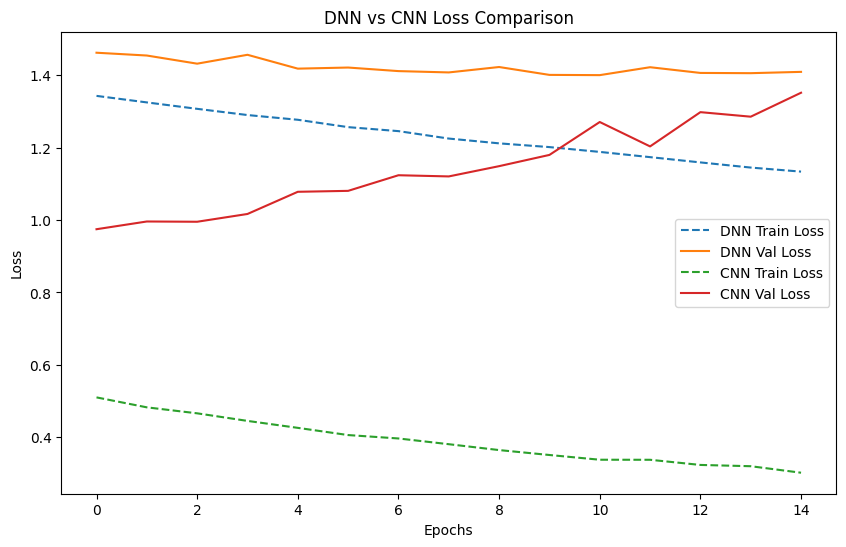

In [ ]:
plt.figure(figsize=(10,6))

# DNN
plt.plot(history_dnn.history['loss'], label='DNN Train Loss', linestyle='--')
plt.plot(history_dnn.history['val_loss'], label='DNN Val Loss')

# CNN
plt.plot(history_cnn.history['loss'], label='CNN Train Loss', linestyle='--')
plt.plot(history_cnn.history['val_loss'], label='CNN Val Loss')

plt.title("DNN vs CNN Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
dnn_acc = history_dnn.history['val_accuracy'][-1]
cnn_acc = history_cnn.history['val_accuracy'][-1]

print("Final Validation Accuracy:")
print(f"DNN: {dnn_acc:.4f}")
print(f"CNN: {cnn_acc:.4f}")

Final Validation Accuracy:
DNN: 0.5173
CNN: 0.7152


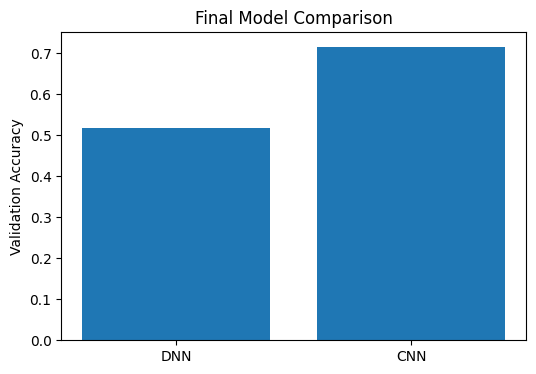

In [ ]:
models = ['DNN', 'CNN']
accuracies = [dnn_acc, cnn_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Final Model Comparison")
plt.ylabel("Validation Accuracy")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def predict_image(index):

    # Get image
    img = x_test_original[index]   # original (not flattened)
    true_label = y_test[index][0]

    # Show image
    plt.imshow(img)
    plt.title(f"Actual: {class_names[true_label]}")
    plt.axis('off')
    plt.show()

    # Preprocess for CNN
    img_cnn = img / 255.0
    img_cnn = np.expand_dims(img_cnn, axis=0)

    # Preprocess for DNN
    img_dnn = img_cnn.reshape(1, -1)

    # Predictions
    cnn_pred = np.argmax(final_cnn.predict(img_cnn), axis=1)[0]
    dnn_pred = np.argmax(final_model1.predict(img_dnn), axis=1)[0]

    print("CNN Prediction:", class_names[cnn_pred])
    print("DNN Prediction:", class_names[dnn_pred])
    print("Actual Label :", class_names[true_label])

##Try verification with internet image


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving ship.jpg to ship.jpg


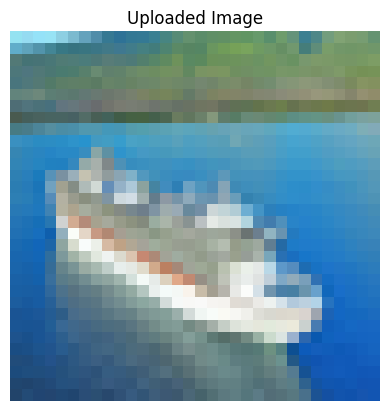

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Get file name
img_name = list(uploaded.keys())[0]

# Open image
img = Image.open(img_name)

# Resize to CIFAR size (32x32)
img = img.resize((32, 32))

# Show image
plt.imshow(img)
plt.title("Uploaded Image")
plt.axis('off')
plt.show()

# Convert to array
img_array = np.array(img)

# Normalize
img_norm = img_array / 255.0

In [ ]:
# CNN input
img_cnn = np.expand_dims(img_norm, axis=0)

# DNN input (flatten)
img_dnn = img_cnn.reshape(1, -1)

# Predictions
cnn_pred = np.argmax(final_cnn.predict(img_cnn), axis=1)[0]
dnn_pred = np.argmax(final_model1.predict(img_dnn), axis=1)[0]

# Class labels
class_names = [
    "Airplane","Automobile","Bird","Cat","Deer",
    "Dog","Frog","Horse","Ship","Truck"
]

print("CNN Prediction:", class_names[cnn_pred])
print("DNN Prediction:", class_names[dnn_pred])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step
CNN Prediction: Ship
DNN Prediction: Ship


In [ ]:
probs = final_cnn.predict(img_cnn)[0]

plt.figure(figsize=(8,4))
plt.bar(class_names, probs)
plt.xticks(rotation=45)
plt.title("CNN Prediction Probabilities")
plt.show()

Tanh Activation performed well with SGD while Relu performed better with Adam